# Multi-View Image to 3D Printable Model with Hunyuan3D-2mv

This notebook generates a 3D printable model from front, side, and back reference images using Tencent's Hunyuan3D-2mv.

## Workflow

1. Install Hunyuan3D-2
2. Check GPU availability
3. Upload multi-view reference images
4. Load Hunyuan3D-2mv
5. Generate the 3D mesh
6. Remove disconnected geometry
7. Export the final model as STL

In [16]:
!git clone -q https://github.com/Tencent-Hunyuan/Hunyuan3D-2.git

%cd /content/Hunyuan3D-2

!pip install -q -r requirements.txt
!pip install -q -e .

print("Installation complete ✅")

/content/Hunyuan3D-2
  Preparing metadata (setup.py) ... done
Installation complete ✅


In [17]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU not detected. Enable a GPU runtime in Google Colab."
    )

CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


In [18]:
from google.colab import files
import os

print("Please upload:")
print("- front.png")
print("- left.png")
print("- back.png")

uploaded = files.upload()

required_files = ["front.png", "left.png", "back.png"]

for filename in required_files:
    path = f"/content/{filename}"

    if os.path.exists(path):
        print(filename, "✅")
    else:
        print(filename, "❌ MISSING")

Please upload:
- front.png
- left.png
- back.png


Saving back.png to back.png
Saving left.png to left.png
Saving front.png to front.png
front.png ✅
left.png ✅
back.png ✅


front.png


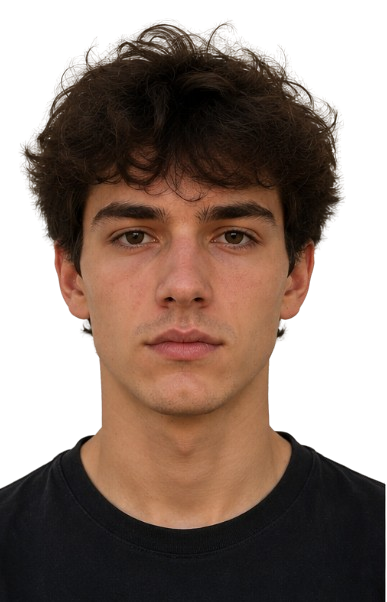

left.png


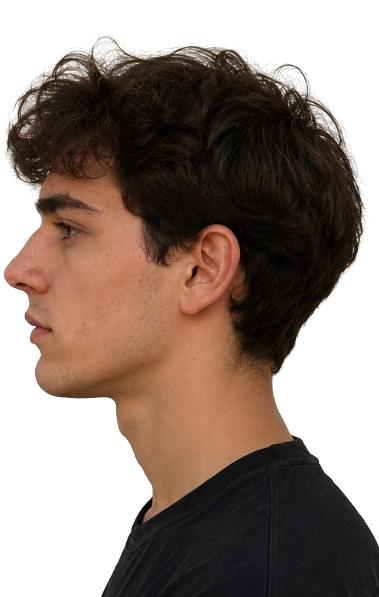

back.png


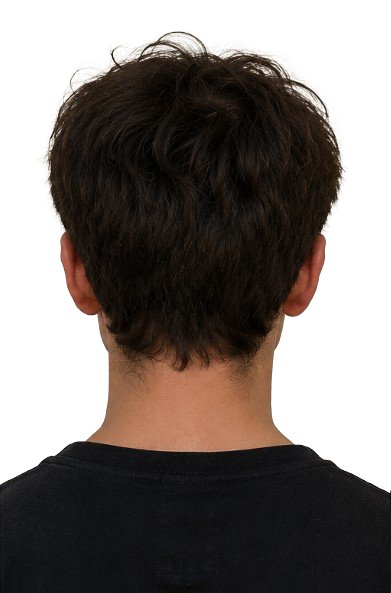

In [19]:
from PIL import Image
from IPython.display import display

for filename in ["front.png", "left.png", "back.png"]:
    print(filename)
    display(Image.open(f"/content/{filename}"))

In [1]:
from hy3dgen.shapegen import Hunyuan3DDiTFlowMatchingPipeline

pipeline = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(
    "tencent/Hunyuan3D-2mv",
    subfolder="hunyuan3d-dit-v2-mv",
    use_safetensors=True,
    device="cuda"
)

print("Hunyuan3D-2mv loaded ✅")

2026-08-18 00:54:24,311 - hy3dgen.shapgen - INFO - Try to load model from local path: /root/.cache/hy3dgen/tencent/Hunyuan3D-2mv/hunyuan3d-dit-v2-mv
INFO:hy3dgen.shapgen:Try to load model from local path: /root/.cache/hy3dgen/tencent/Hunyuan3D-2mv/hunyuan3d-dit-v2-mv
2026-08-18 00:54:24,314 - hy3dgen.shapgen - INFO - Model path not exists, try to download from huggingface
INFO:hy3dgen.shapgen:Model path not exists, try to download from huggingface


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

2026-08-18 00:54:25,148 - hy3dgen.shapgen - INFO - Loading model from /root/.cache/huggingface/hub/models--tencent--Hunyuan3D-2mv/snapshots/3a761b539b29fe4ff64714813aa9560fd66f5de0/hunyuan3d-dit-v2-mv/model.fp16.safetensors
INFO:hy3dgen.shapgen:Loading model from /root/.cache/huggingface/hub/models--tencent--Hunyuan3D-2mv/snapshots/3a761b539b29fe4ff64714813aa9560fd66f5de0/hunyuan3d-dit-v2-mv/model.fp16.safetensors


PointCrossAttentionEncoder INFO: pc_sharpedge_size is given, using pc_size=5120, pc_sharpedge_size=5120
Hunyuan3D-2mv loaded ✅


In [2]:
images = {
    "front": "/content/front.png",
    "left": "/content/left.png",
    "back": "/content/back.png"
}

print("Reference views ready ✅")

Reference views ready ✅


In [3]:
import torch

mesh = pipeline(
    image=images,
    num_inference_steps=30,
    octree_resolution=380,
    num_chunks=20000,
    generator=torch.manual_seed(12345),
    output_type="trimesh"
)[0]

print("3D model generated ✅")
print("Vertices:", len(mesh.vertices))
print("Faces:", len(mesh.faces))
print("Watertight:", mesh.is_watertight)

Volume Decoding: 100%|██████████| 2766/2766 [02:11<00:00, 21.00it/s]


3D model generated ✅
Vertices: 518950
Faces: 1038190
Watertight: False


In [4]:
mesh.export("/content/model_raw.stl")

print("Raw STL saved ✅")

Raw STL saved ✅


In [5]:
import trimesh

parts = mesh.split(only_watertight=False)

print("Connected components:", len(parts))

for i, part in enumerate(parts):
    print(
        f"Part {i}:",
        "Faces =", len(part.faces),
        "Vertices =", len(part.vertices),
        "Size =", part.bounding_box.extents
    )

Connected components: 93
Part 0: Faces = 1024916 Vertices = 512144 Size = [1.43065178 1.99198472 1.40528953]
Part 1: Faces = 136 Vertices = 70 Size = [0.02191776 0.02090041 0.02599167]
Part 2: Faces = 180 Vertices = 92 Size = [0.01653752 0.01498795 0.05411214]
Part 3: Faces = 28 Vertices = 16 Size = [0.00457925 0.01304573 0.01141582]
Part 4: Faces = 1 Vertices = 2 Size = [0.         0.00401729 0.00530183]
Part 5: Faces = 1 Vertices = 1 Size = [0. 0. 0.]
Part 6: Faces = 1 Vertices = 2 Size = [0.00530183 0.         0.00357977]
Part 7: Faces = 1 Vertices = 2 Size = [0.00530183 0.00297788 0.        ]
Part 8: Faces = 76 Vertices = 40 Size = [0.01127619 0.01184094 0.01879986]
Part 9: Faces = 84 Vertices = 44 Size = [0.01154083 0.01475495 0.01947159]
Part 10: Faces = 384 Vertices = 194 Size = [0.048127   0.0437516  0.04510099]
Part 11: Faces = 228 Vertices = 116 Size = [0.0296759  0.03024185 0.02549034]
Part 12: Faces = 140 Vertices = 72 Size = [0.02436179 0.02335474 0.01670679]
Part 13: Face

In [6]:
largest_part = max(parts, key=lambda part: len(part.faces))

clean_mesh = largest_part.copy()

print("Clean mesh created ✅")
print("Vertices:", len(clean_mesh.vertices))
print("Faces:", len(clean_mesh.faces))
print("Watertight:", clean_mesh.is_watertight)

Clean mesh created ✅
Vertices: 512144
Faces: 1024916
Watertight: True


In [8]:
clean_mesh.export("/content/model_clean.stl")

print("Final STL exported ✅")

Final STL exported ✅


In [9]:
from google.colab import files

files.download("/content/model_clean.stl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>